In [1]:
# No Code/Low Code Visual ML Project
# Objective: Leverage no-code/low-code tools for machine learning using Tesla stock data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from statsmodels.tsa.arima.model import ARIMA

# Load the dataset
data = pd.read_csv('./TSLA.csv')

# Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Sort data by Date
data = data.sort_values('Date')

# Feature Engineering
# Calculate daily returns and add as a feature
data['Daily_Return'] = data['Close'].pct_change()
# Add a binary classification column: 1 if the return is positive, 0 otherwise
data['Positive_Return'] = (data['Daily_Return'] > 0).astype(int)
# Calculate moving averages
window_sizes = [20, 50, 200]
for window in window_sizes:
    data[f'{window}_MA'] = data['Close'].rolling(window=window).mean()

# Handle Missing Values
data.fillna(method='bfill', inplace=True)


/var/folders/1g/wmgqn3xd181cczh_vn2lyjj80000gn/T/ipykernel_74128/957061663.py:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)


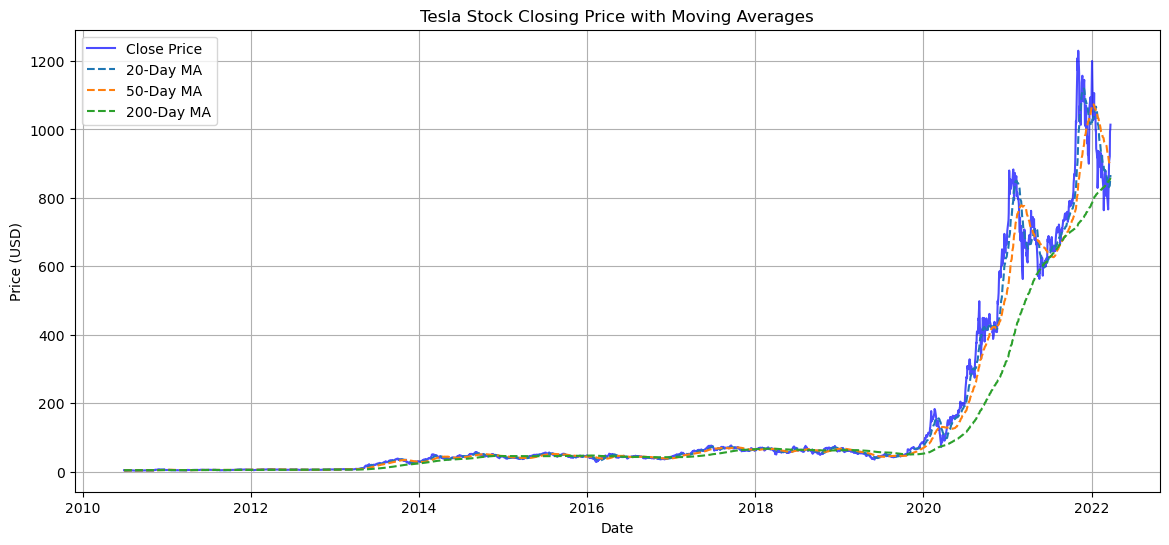

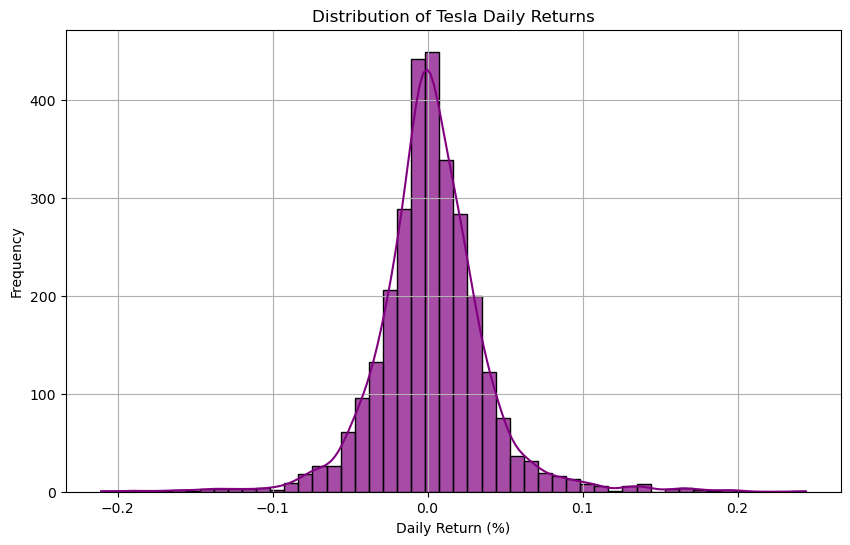

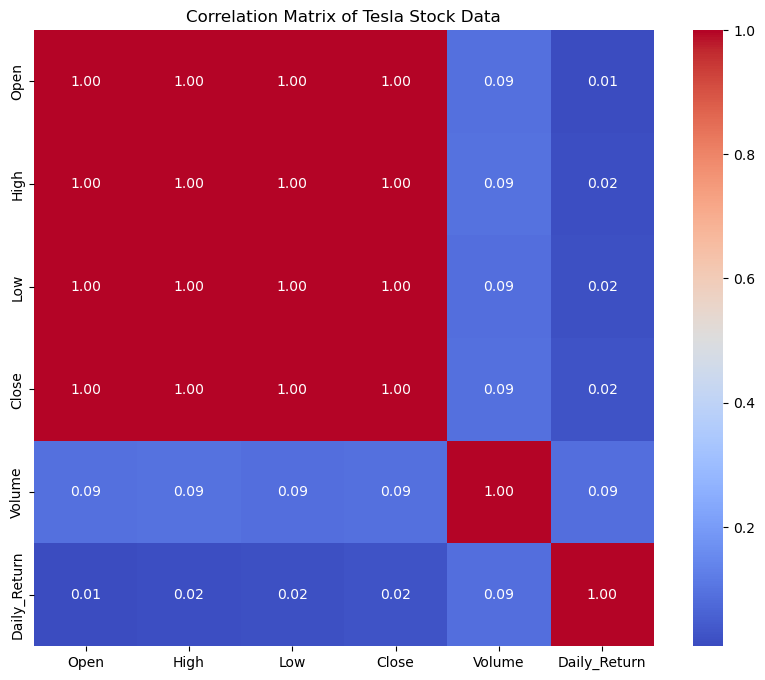

In [2]:
# Static Visualizations
# Plot closing price and moving averages
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', color='blue', alpha=0.7)
for window in window_sizes:
    plt.plot(data['Date'], data[f'{window}_MA'], label=f'{window}-Day MA', linestyle='--')
plt.title('Tesla Stock Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

# Distribution Analysis of Daily Returns
plt.figure(figsize=(10, 6))
sns.histplot(data['Daily_Return'].dropna(), bins=50, kde=True, color='purple', alpha=0.7)
plt.title('Distribution of Tesla Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

# Correlation Analysis
correlation_matrix = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Tesla Stock Data')
plt.show()

In [4]:
# Predictive Modeling
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = data[features]
y_classification = data['Positive_Return']
y_regression = data['Close']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train_class, y_test_class = train_test_split(X_scaled, y_classification, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled, y_regression, test_size=0.2, random_state=42)



In [5]:
# Classification: Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train_class)
y_pred_class = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test_class, y_pred_class))

# Regression: Decision Tree
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)

print("Mean Absolute Error for Regression:", mean_absolute_error(y_test_reg, y_pred_reg))
print("Mean Squared Error for Regression:", mean_squared_error(y_test_reg, y_pred_reg))

# Clustering: K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
data['Cluster'] = kmeans.labels_


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       291
           1       0.72      0.72      0.72       301

    accuracy                           0.72       592
   macro avg       0.72      0.72      0.72       592
weighted avg       0.72      0.72      0.72       592

Mean Absolute Error for Regression: 0.5944927280405401
Mean Squared Error for Regression: 7.0214687903812525


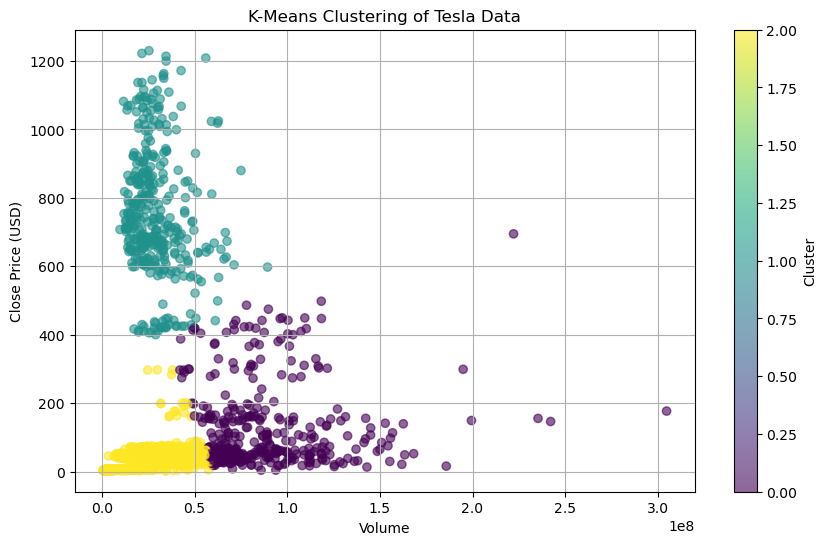

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2956
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -11327.212
Date:                Fri, 03 Jan 2025   AIC                          22666.424
Time:                        23:14:19   BIC                          22702.372
Sample:                             0   HQIC                         22679.365
                               - 2956                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0094      0.006     -1.502      0.133      -0.022       0.003
ar.L2         -0.0172      0.006     -3.015      0.003      -0.028      -0.006
ar.L3          0.0185      0.008      2.456      0.0

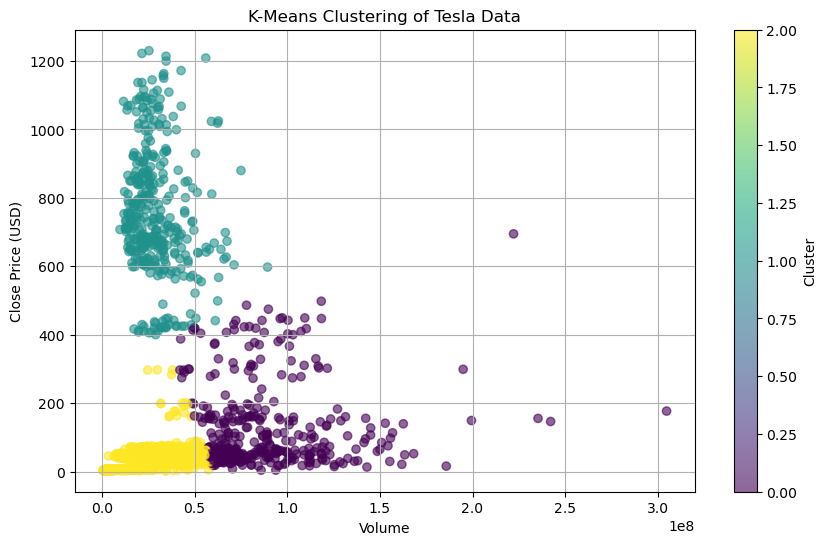

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2956
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -11327.212
Date:                Fri, 03 Jan 2025   AIC                          22666.424
Time:                        23:14:19   BIC                          22702.372
Sample:                             0   HQIC                         22679.365
                               - 2956                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0094      0.006     -1.502      0.133      -0.022       0.003
ar.L2         -0.0172      0.006     -3.015      0.003      -0.028      -0.006
ar.L3          0.0185      0.008      2.456      0.0

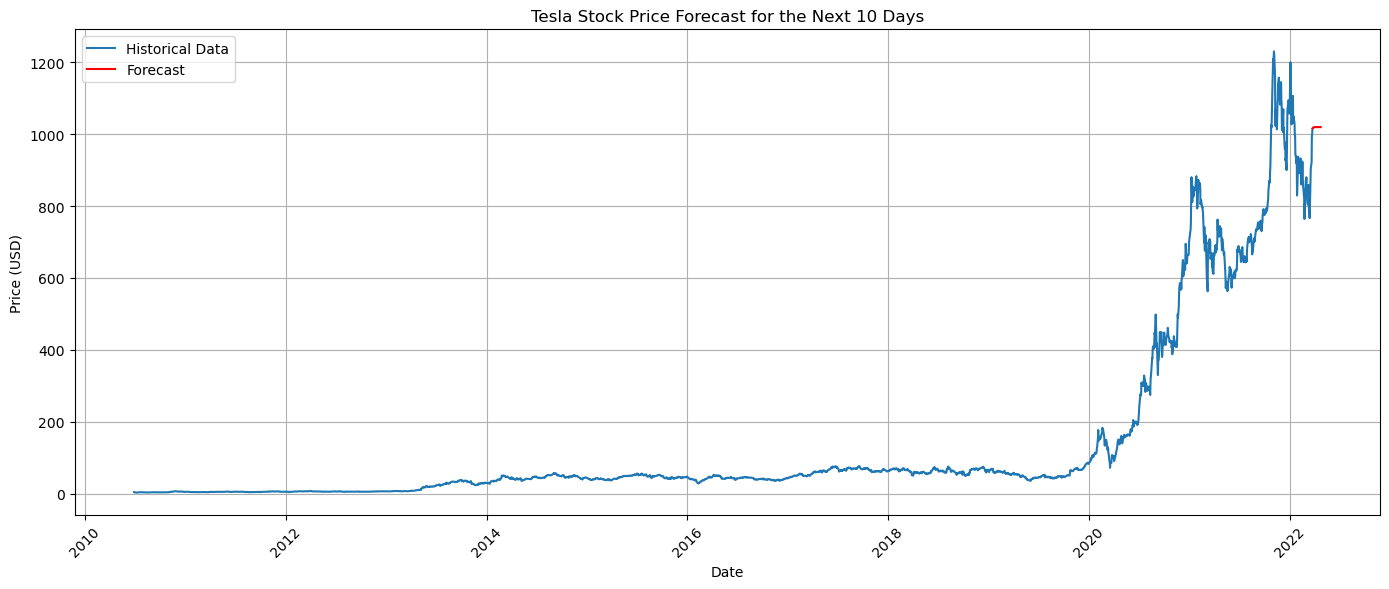

In [8]:
# Visualize Clusters
plt.figure(figsize=(10, 6))
plt.scatter(data['Volume'], data['Close'], c=data['Cluster'], cmap='viridis', alpha=0.6)
plt.title('K-Means Clustering of Tesla Data')
plt.xlabel('Volume')
plt.ylabel('Close Price (USD)')
plt.colorbar(label='Cluster')
plt.grid()
plt.show()

# Time-Series Forecasting with ARIMA
arima_model = ARIMA(data['Close'], order=(5, 1, 0))
arima_fit = arima_model.fit()
print(arima_fit.summary())

# Updated Capstone Project Codes for Enhanced Analysis and Visualization
X_train, X_test, y_train_class, y_test_class = train_test_split(X_scaled, y_classification, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_scaled, y_regression, test_size=0.2, random_state=42)

# Classification: Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train_class)
y_pred_class = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test_class, y_pred_class))

# Regression: Decision Tree
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)

print("Mean Absolute Error for Regression:", mean_absolute_error(y_test_reg, y_pred_reg))
print("Mean Squared Error for Regression:", mean_squared_error(y_test_reg, y_pred_reg))

# Clustering: K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
data['Cluster'] = kmeans.labels_

# Visualize Clusters
plt.figure(figsize=(10, 6))
plt.scatter(data['Volume'], data['Close'], c=data['Cluster'], cmap='viridis', alpha=0.6)
plt.title('K-Means Clustering of Tesla Data')
plt.xlabel('Volume')
plt.ylabel('Close Price (USD)')
plt.colorbar(label='Cluster')
plt.grid()
plt.show()

# Time-Series Forecasting with ARIMA
arima_model = ARIMA(data['Close'], order=(5, 1, 0))
arima_fit = arima_model.fit()
print(arima_fit.summary())

# Forecast Next 10 Days
forecast = arima_fit.forecast(steps=30)
forecast_dates = pd.date_range(data['Date'].iloc[-1] + pd.Timedelta(days=1), periods=30, freq='D')

plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Historical Data')
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.title('Tesla Stock Price Forecast for the Next 10 Days')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary:
# - Enhanced feature engineering with moving averages and binary classification labels.
# - Applied Random Forest for classification, Decision Tree for regression, and K-Means for clustering.
# - Incorporated ARIMA for time-series forecasting with an improved and readable 10-day forecast graph.


# Summary:
# - Enhanced feature engineering with moving averages and binary classification labels.
# - Applied Random Forest for classification, Decision Tree for regression, and K-Means for clustering.
# - Incorporated ARIMA for time-series forecasting.